Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os


Absolute pathfix

In [2]:
import sys
import os

# 1. Get the current folder (root/notebooks)
current_dir = os.getcwd()

# 2. Get the parent folder (root) where database.py lives
parent_dir = os.path.dirname(current_dir)

# 3. Add the parent folder to Python's search path
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

print(f"Current Directory: {current_dir}")
print(f"Parent Directory (Added to Path): {parent_dir}")

# 4. Verify we can see the file now
try:
    import database
    print("✅ Success: 'database' module found.")
except ImportError:
    print("❌ Error: Still cannot find 'database'. Double check that database.py is in the parent folder.")

Current Directory: D:\Projects\orbit_recommender\notebooks
Parent Directory (Added to Path): D:\Projects\orbit_recommender
✅ Success: 'database' module found.


Some more imports

In [3]:
# Surprise Library Imports
from surprise import Dataset, Reader, SVD, accuracy, dump
from surprise.model_selection import train_test_split

# Your custom database imports (Ensure database.py is in the same folder)
from sqlalchemy.orm import Session
from database import SessionLocal, Interaction

# Configuration
MODEL_PATH = "models/svd_model.pkl"
sns.set_style("whitegrid") # For better looking charts

print("Libraries loaded successfully.")

Libraries loaded successfully.


Data Loading & Processing

In [ ]:
def load_and_process_data():
    """
    Fetches interaction data from DB and processes it into a DataFrame.
    """
    db: Session = SessionLocal()
    try:
        query = db.query(Interaction).statement
        df = pd.read_sql(query, db.bind)
    except Exception as e:
        print(f"Error connecting to database: {e}")
        return pd.DataFrame(), pd.DataFrame()
    finally:
        db.close()
    
    if df.empty:
        print("Warning: No interactions found in DB.")
        return pd.DataFrame(), pd.DataFrame()

    # --- THE FIX IS HERE ---
    # Old Weights: view=1, click=2, cart=3, purchase=5
    
    weights = {
        'view': 0.2,        # Drastically reduced (was 1.0)
        'click': 0.5,       # Reduced (was 2.0)
        'add_to_cart': 3.0, # Kept high (strong signal)
        'purchase': 5.0     # Kept high (strongest signal)
    }
    
    # Apply weights
    df['score'] = df['interaction_type'].map(weights)
    
    # Aggregate: If user views AND buys, take the max score
    df_final = df.groupby(['user_id', 'product_id'])['score'].max().reset_index()
    
    return df_final, df

# Execute loading
df_model, df_raw = load_and_process_data()

print(f"Total Raw Interactions: {len(df_raw)}")
print(f"Unique User-Item Pairs: {len(df_model)}")
df_model.head()

Total Raw Interactions: 2313
Unique User-Item Pairs: 2012


,user_id,product_id,score
0,,B01MZ81RQ0,0.5
1,,B0C1RL4296,0.5
2,1001,B0000C73CQ,5.0
3,1001,B000GFEYU6,3.0
4,1001,B000H9HQ4M,3.0


Analytics & Visuals

C:\Users\adity\AppData\Local\Temp\ipykernel_4172\3208668142.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='score', data=df_model, palette='viridis')


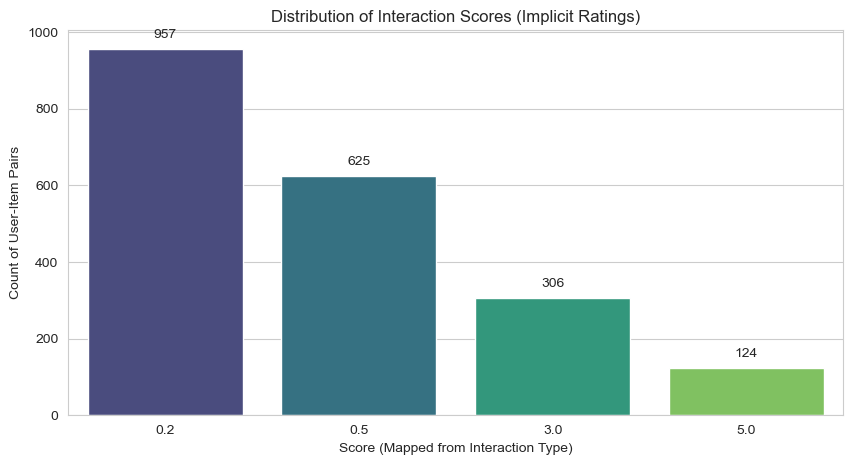

In [5]:
if not df_model.empty:
    plt.figure(figsize=(10, 5))
    
    # Plotting the distribution of scores (1.0, 2.0, 3.0, 5.0)
    ax = sns.countplot(x='score', data=df_model, palette='viridis')
    
    plt.title("Distribution of Interaction Scores (Implicit Ratings)")
    plt.xlabel("Score (Mapped from Interaction Type)")
    plt.ylabel("Count of User-Item Pairs")
    
    # Add count labels on top of bars
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha = 'center', va = 'center', xytext = (0, 10), textcoords = 'offset points')
    
    plt.show()
else:
    print("No data to visualize.")

Model Evaluation

In [6]:
if not df_model.empty:
    # 1. Define the Reader (1-5 scale based on your weights)
    reader = Reader(rating_scale=(1, 5))
    
    # 2. Load data into Surprise format
    data = Dataset.load_from_df(df_model[['user_id', 'product_id', 'score']], reader)
    
    # 3. Perform Train-Test Split (80% Train, 20% Test)
    trainset, testset = train_test_split(data, test_size=0.20, random_state=42)
    
    # 4. Initialize SVD with your EXACT parameters
    print("Initializing SVD with custom params...")
    model = SVD(n_factors=50, n_epochs=20, lr_all=0.005, reg_all=0.02)
    
    # 5. Train on the 80% split
    print("Training on 80% of the data...")
    model.fit(trainset)
    
    # 6. Test on the 20% split
    print("Evaluating on the remaining 20%...")
    predictions = model.test(testset)
    
    # 7. Calculate Accuracy Metrics
    print("\nModel Accuracy Results:")
    rmse = accuracy.rmse(predictions)
    mae = accuracy.mae(predictions)
else:
    print("Skipping evaluation: No data available.")

Initializing SVD with custom params...
Training on 80% of the data...
Evaluating on the remaining 20%...

Model Accuracy Results:
RMSE: 1.3833
MAE:  1.1173


Final Training & Saving

In [7]:
if not df_model.empty:
    print("Retraining model on FULL dataset for production...")
    
    # Build full trainset
    full_trainset = data.build_full_trainset()
    
    # Re-initialize model to ensure a fresh start
    final_model = SVD(n_factors=50, n_epochs=20, lr_all=0.005, reg_all=0.02)
    
    # Fit full data
    final_model.fit(full_trainset)
    
    # Ensure directory exists
    os.makedirs(os.path.dirname(MODEL_PATH), exist_ok=True)
    
    # Dump (Save) the model
    dump.dump(MODEL_PATH, algo=final_model)
    print(f"✅ Final model saved successfully to: {MODEL_PATH}")

else:
    print("Skipping save: No data available.")

Retraining model on FULL dataset for production...
✅ Final model saved successfully to: models/svd_model.pkl


Inference Test

In [8]:
def predict_user_preference(user_id, product_id):
    """
    Loads the saved model and predicts score.
    """
    if not os.path.exists(MODEL_PATH):
        return "Error: Model file not found."
    
    # Load model (surprise.dump.load returns (predictions, algorithm))
    _, loaded_model = dump.load(MODEL_PATH)
    
    # Predict
    # Note: convert IDs to strings as Surprise expects string IDs usually
    prediction = loaded_model.predict(str(user_id), str(product_id))
    
    return {
        "User": 2000,
        "Product": "B07SDFLVKD",
        "Predicted_Score": round(prediction.est, 4),
        "Details": prediction
    }

# Example usage (Replace with actual IDs from your DB)
test_user_id = df_model['user_id'].iloc[0] if not df_model.empty else 1
test_prod_id = df_model['product_id'].iloc[0] if not df_model.empty else 101

print(predict_user_preference(test_user_id, test_prod_id))

{'User': 2000, 'Product': 'B07SDFLVKD', 'Predicted_Score': 1, 'Details': Prediction(uid='', iid='B01MZ81RQ0', r_ui=None, est=1, details={'was_impossible': False})}
